In [1]:
import matplotlib.pyplot as plt
import scanpy as sc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

import kktk

import matplotlib as mpl
# enables correct plotting of text
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42 

/rfs/project/rfs-iCNyzSAaucw/kk837/github/kktk/kktk/plotting.py:21: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  if sc.__version__.startswith("1.4"):


In [2]:
import session_info
session_info.show()

/home/kk837/.conda/envs/generic_env/lib/python3.10/site-packages/session_info/main.py:213: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  mod_version = _find_version(mod.__version__)
/home/kk837/.conda/envs/generic_env/lib/python3.10/site-packages/session_info/main.py:213: UserWarning: The '__version__' attribute is deprecated and will be removed in MarkupSafe 3.1. Use feature detection, or `importlib.metadata.version("markupsafe")`, instead.
  mod_version = _find_version(mod.__version__)


In [3]:
sc.settings.set_figure_params(dpi=80)

# Function

In [6]:
# https://cell2location.readthedocs.io/en/latest/notebooks/cell2location_short_demo.html
def select_slide(adata, s, s_col='sample'):
    r""" This function selects the data for one slide from the spatial anndata object.

    :param adata: Anndata object with multiple spatial experiments
    :param s: name of selected experiment
    :param s_col: column in adata.obs listing experiment name for each location
    """

    slide = adata[adata.obs[s_col].isin([s]), :]
    s_keys = list(slide.uns['spatial'].keys())
    s_spatial = np.array(s_keys)[[s in k for k in s_keys]][0]

    slide.uns['spatial'] = {s_spatial: slide.uns['spatial'][s_spatial]}

    return slide

# Variables

In [4]:
data_object_dir = '/rfs/project/rfs-iCNyzSAaucw/kk837/data_objects/Foetal/VisiumHD/Revision_Oct2025/TACCO/coarse_grain_subsets'
celltype = 'AtrialCardiomyocytes'
adata_path = f'{data_object_dir}/b2c_cells_{celltype}_lognorm.h5ad'
celltype_key = 'fine_grain2'

In [5]:
!ls {data_object_dir}

b2c_cells_AtrialCardiomyocytes_lognorm.h5ad
b2c_cells_EndothelialCells_lognorm.h5ad
b2c_cells_EndothelialCells_raw.h5ad
b2c_cells_EpicardialCells_lognorm.h5ad
b2c_cells_EpicardialCells_raw.h5ad
b2c_cells_LymphoidCells_lognorm.h5ad
b2c_cells_LymphoidCells_raw.h5ad
b2c_cells_MesenchymalCells_lognorm.h5ad
b2c_cells_MesenchymalCells_raw.h5ad
b2c_cells_MyeloidCells_lognorm.h5ad
b2c_cells_MyeloidCells_raw.h5ad
b2c_cells_NeuralCells_lognorm.h5ad
b2c_cells_NeuralCells_raw.h5ad
b2c_cells_SinoatrialNodePacemakerCells_lognorm.h5ad
b2c_cells_VentricularCardiomyocytes_lognorm.h5ad
b2c_cells_VentricularCardiomyocytes_raw.h5ad
scVI


In [7]:
# figdir = '/nfs/team205/heart/fetal_ms_figures/raw_plots_kk/Aug2024'
# table_dir = '/nfs/team205/heart/fetal_ms_figures/tables/Aug2024'

# Read in data

In [8]:
# read in aCM annotated data
adata = sc.read_h5ad(adata_path)
print(adata.X.data[:5])
adata

[2.30024843 2.30024843 2.30024843 2.30024843 2.30024843]


AnnData object with n_obs × n_vars = 34193 × 17854
    obs: 'object_id', 'bin_count', 'array_row', 'array_col', 'labels_joint_source', 'in_tissue_manual', 'library', 'donor_section_ID', 'per-frame_donorIDs', 'donor', 'CS', 'est_CS', 'GA', 'PCW', 'section_ID', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'library_donor', 'n_genes', 'coarse_grain_pre', 'coarse_grain_pre_2', 'coarse_grain_tacco_ref-hd-scn', 'original_cellid_celltype', 'tacco_max_compscore', 'scVI_leiden_0.2', 'scVI_leiden_0.3', 'scVI_leiden_0.4', 'scVI_leiden_0.5', 'scVI_leiden_0.8', 'scVI_leiden_1.0', 'scVI_leiden_1.5', 'scVI_leiden_2.0', 'scVI_leiden_3.0', 'scVI_leiden_4.0', 'fine_grain', 'fine_grain2'
    var: 'gene_ids', 'feature_types', 'genome', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_m

# Subset SANPCs

In [9]:
set(adata.obs[celltype_key])

{'AtrialCardiomyocytesLeft',
 'AtrialCardiomyocytesNeurotropic',
 'AtrialCardiomyocytesRight',
 'AtrialCardiomyocytesTransitional',
 'AtrioventricularNodePacemakerCells',
 'Doublets',
 'Erythrocytes',
 'SinoatrialNodePacemakerCellsHead',
 'SinoatrialNodePacemakerCellsTail',
 'SinoatrialNodePacemakerCells_lowcounts',
 'SinoatrialNodePacemakerCells_unclassified',
 'SinusHornPacemakerCells'}

In [10]:
adata_sub = adata[adata.obs[celltype_key].isin([
    'SinusHornPacemakerCells',
    'SinoatrialNodePacemakerCellsHead',
    'SinoatrialNodePacemakerCellsTail',
])]
adata_sub

View of AnnData object with n_obs × n_vars = 3380 × 17854
    obs: 'object_id', 'bin_count', 'array_row', 'array_col', 'labels_joint_source', 'in_tissue_manual', 'library', 'donor_section_ID', 'per-frame_donorIDs', 'donor', 'CS', 'est_CS', 'GA', 'PCW', 'section_ID', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'library_donor', 'n_genes', 'coarse_grain_pre', 'coarse_grain_pre_2', 'coarse_grain_tacco_ref-hd-scn', 'original_cellid_celltype', 'tacco_max_compscore', 'scVI_leiden_0.2', 'scVI_leiden_0.3', 'scVI_leiden_0.4', 'scVI_leiden_0.5', 'scVI_leiden_0.8', 'scVI_leiden_1.0', 'scVI_leiden_1.5', 'scVI_leiden_2.0', 'scVI_leiden_3.0', 'scVI_leiden_4.0', 'fine_grain', 'fine_grain2'
    var: 'gene_ids', 'feature_types', 'genome', 'mt', 'n_cells_by_counts', 'mean_counts', '

# Neighbourhood graph, UMAP, and Clustering

In [11]:
import scanpy.external as sce

/home/kk837/.conda/envs/generic_env/lib/python3.10/site-packages/scanpy/preprocessing/_highly_variable_genes.py:744: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns["hvg"] = {"flavor": flavor}
/home/kk837/.conda/envs/generic_env/lib/python3.10/site-packages/scanpy/preprocessing/_pca/__init__.py:226: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  mask_var_param, mask_var = _handle_mask_var(


number of hvgs: 2617


2026-02-09 16:55:14,867 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
2026-02-09 16:55:16,316 - harmonypy - INFO - sklearn.KMeans initialization complete.
2026-02-09 16:55:16,366 - harmonypy - INFO - Iteration 1 of 10
2026-02-09 16:55:16,744 - harmonypy - INFO - Iteration 2 of 10
2026-02-09 16:55:17,098 - harmonypy - INFO - Converged after 2 iterations
/home/kk837/.conda/envs/generic_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


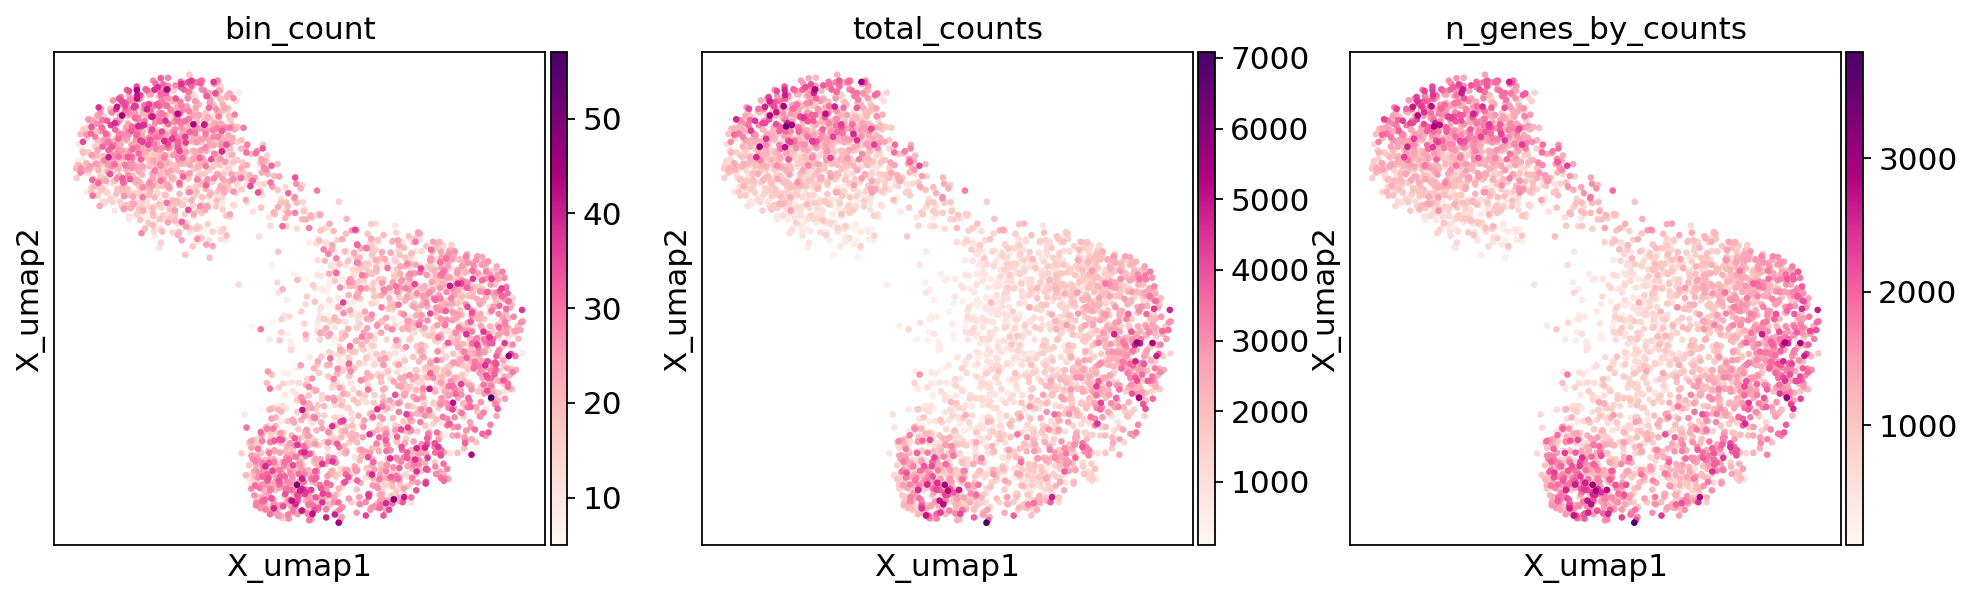

/tmp/ipykernel_3075159/3472086095.py:20: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata_sub,resolution=resolution,key_added=f'leiden_{str(resolution)}',n_iterations=2)


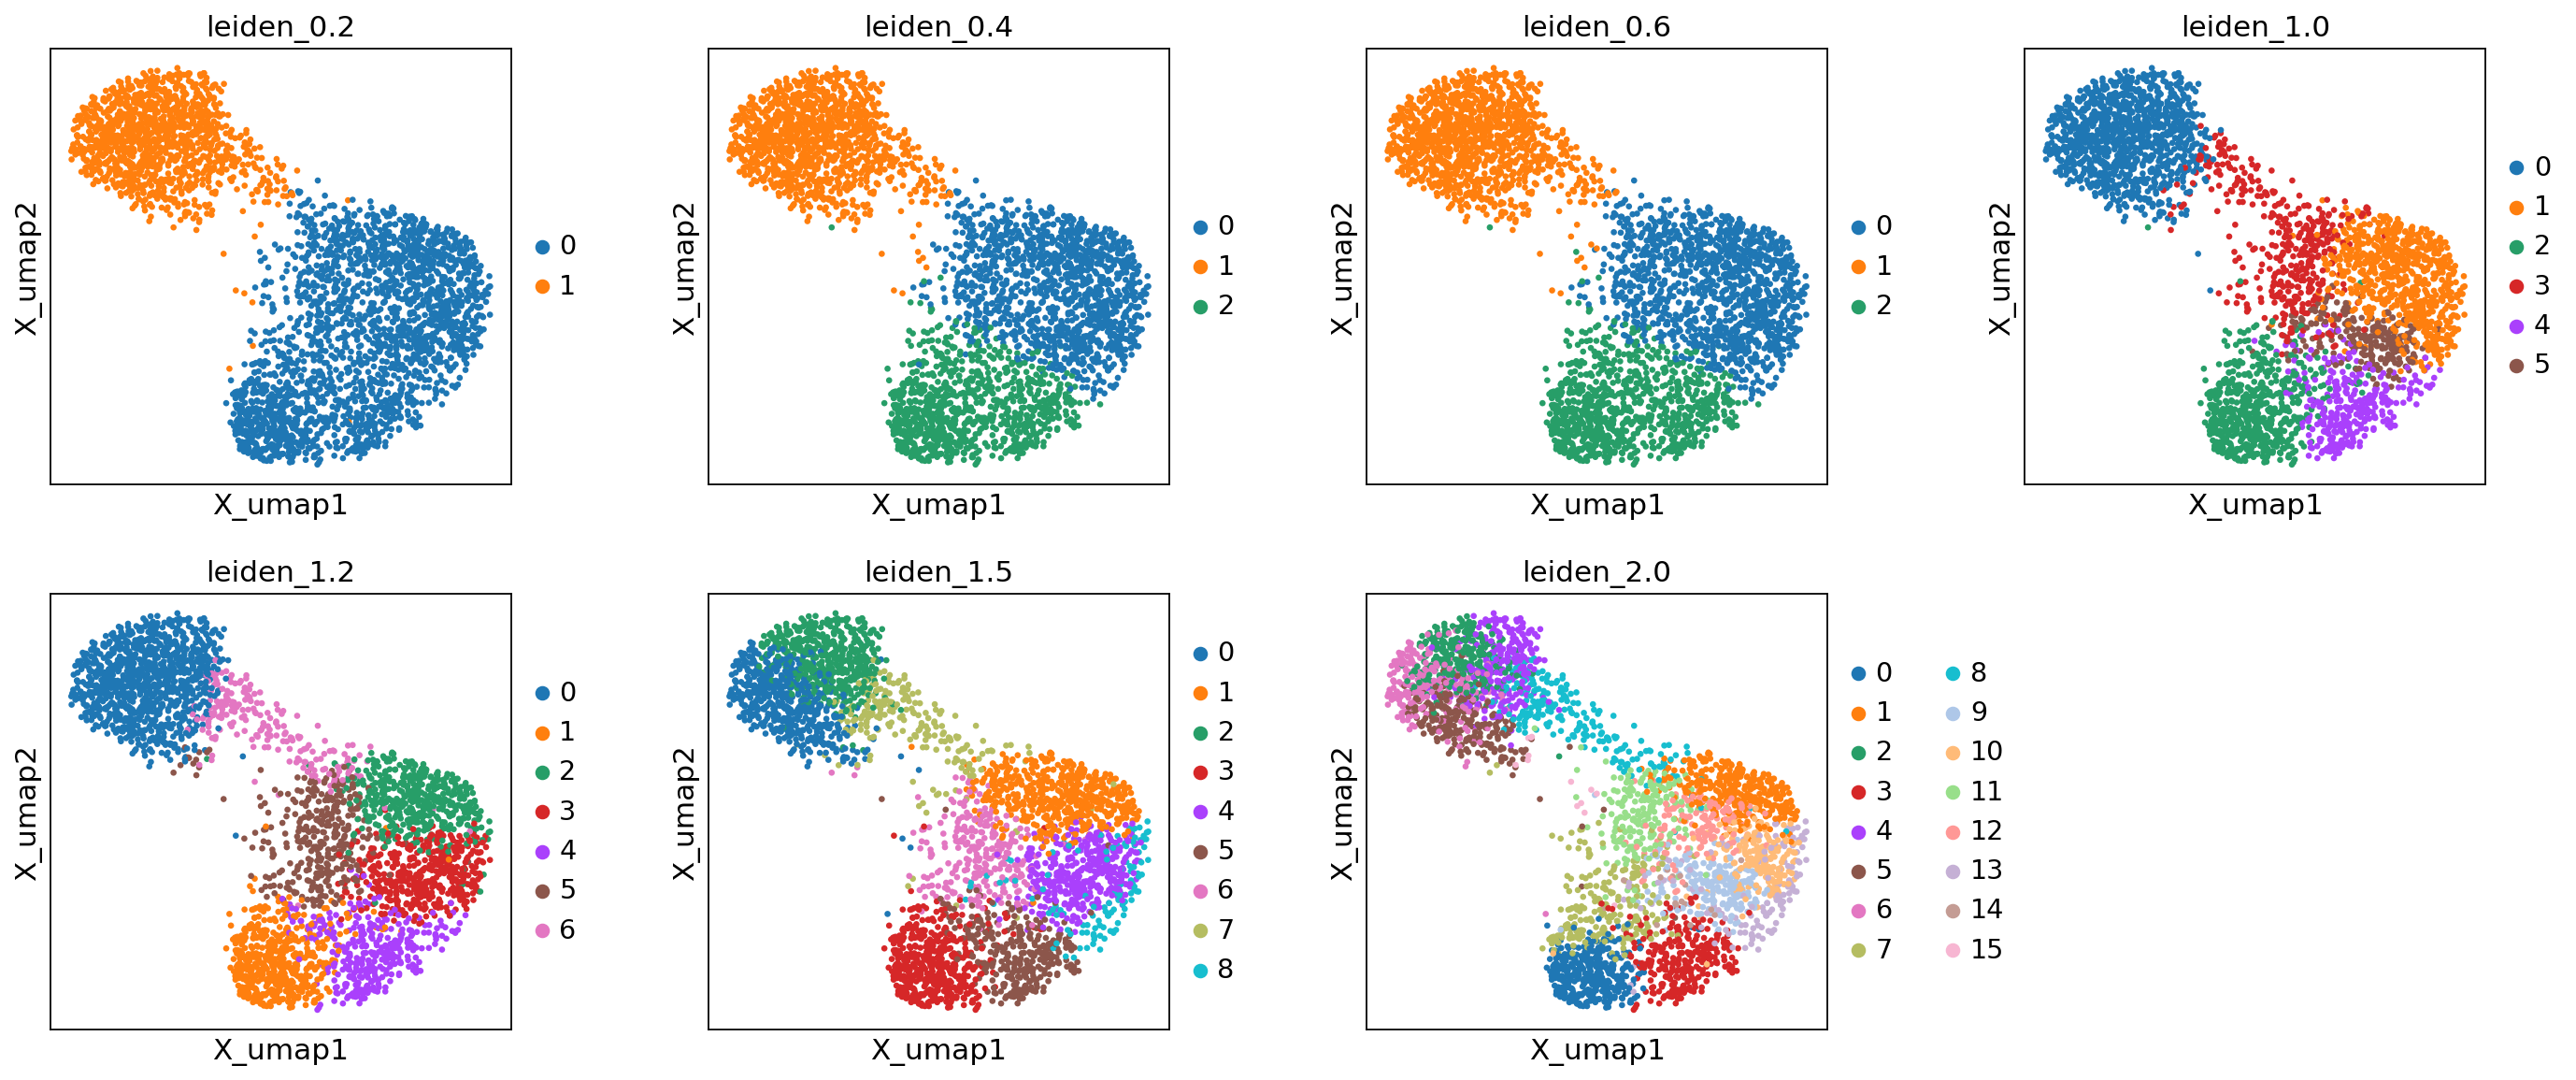

In [12]:
# HVGs, using the object which doesn't have midgrain markers
sc.pp.highly_variable_genes(adata_sub, flavor='seurat', 
                            min_mean=0.0125, max_mean=3, min_disp=0.5, 
                            batch_key='donor')
print(f'number of hvgs: {sum(adata_sub.var.highly_variable)}')
# PCA using the degected HVGs
sc.tl.pca(adata_sub, use_highly_variable=True)
# batch correction using harmony
sce.pp.harmony_integrate(adata_sub, "donor")
# create neighbour graph
sc.pp.neighbors(adata_sub,n_neighbors=15,use_rep='X_pca_harmony')
# visualisation with umap
sc.tl.umap(adata_sub,min_dist=0.2)
sc.pl.embedding(adata_sub,basis='X_umap',
                color=['bin_count','total_counts','n_genes_by_counts'],
                wspace=0.2,cmap='RdPu',vmax='p100',ncols=5)
# leiden clustering
resolutions_list = [0.2,0.4,0.6,1.0,1.2,1.5,2.0]
for resolution in resolutions_list:
    sc.tl.leiden(adata_sub,resolution=resolution,key_added=f'leiden_{str(resolution)}',n_iterations=2)
sc.pl.embedding(adata_sub,basis='X_umap',
                color=[f'leiden_{str(resolution)}' for resolution in resolutions_list],
                wspace=0.3)

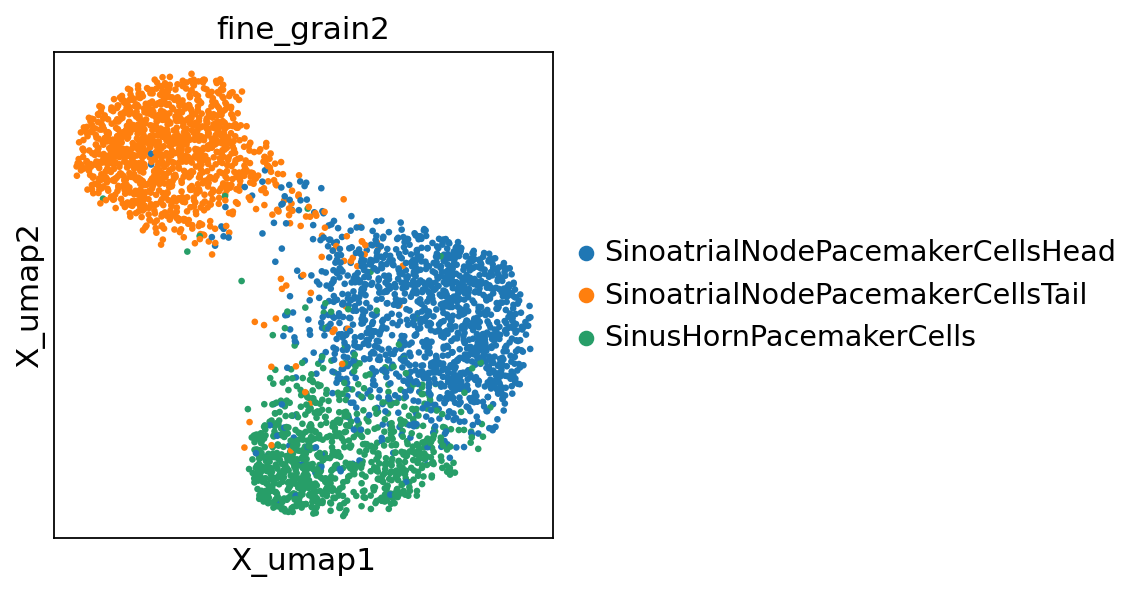

In [13]:
sc.pl.embedding(adata_sub,basis='X_umap',
                color=celltype_key,
                wspace=0.3)

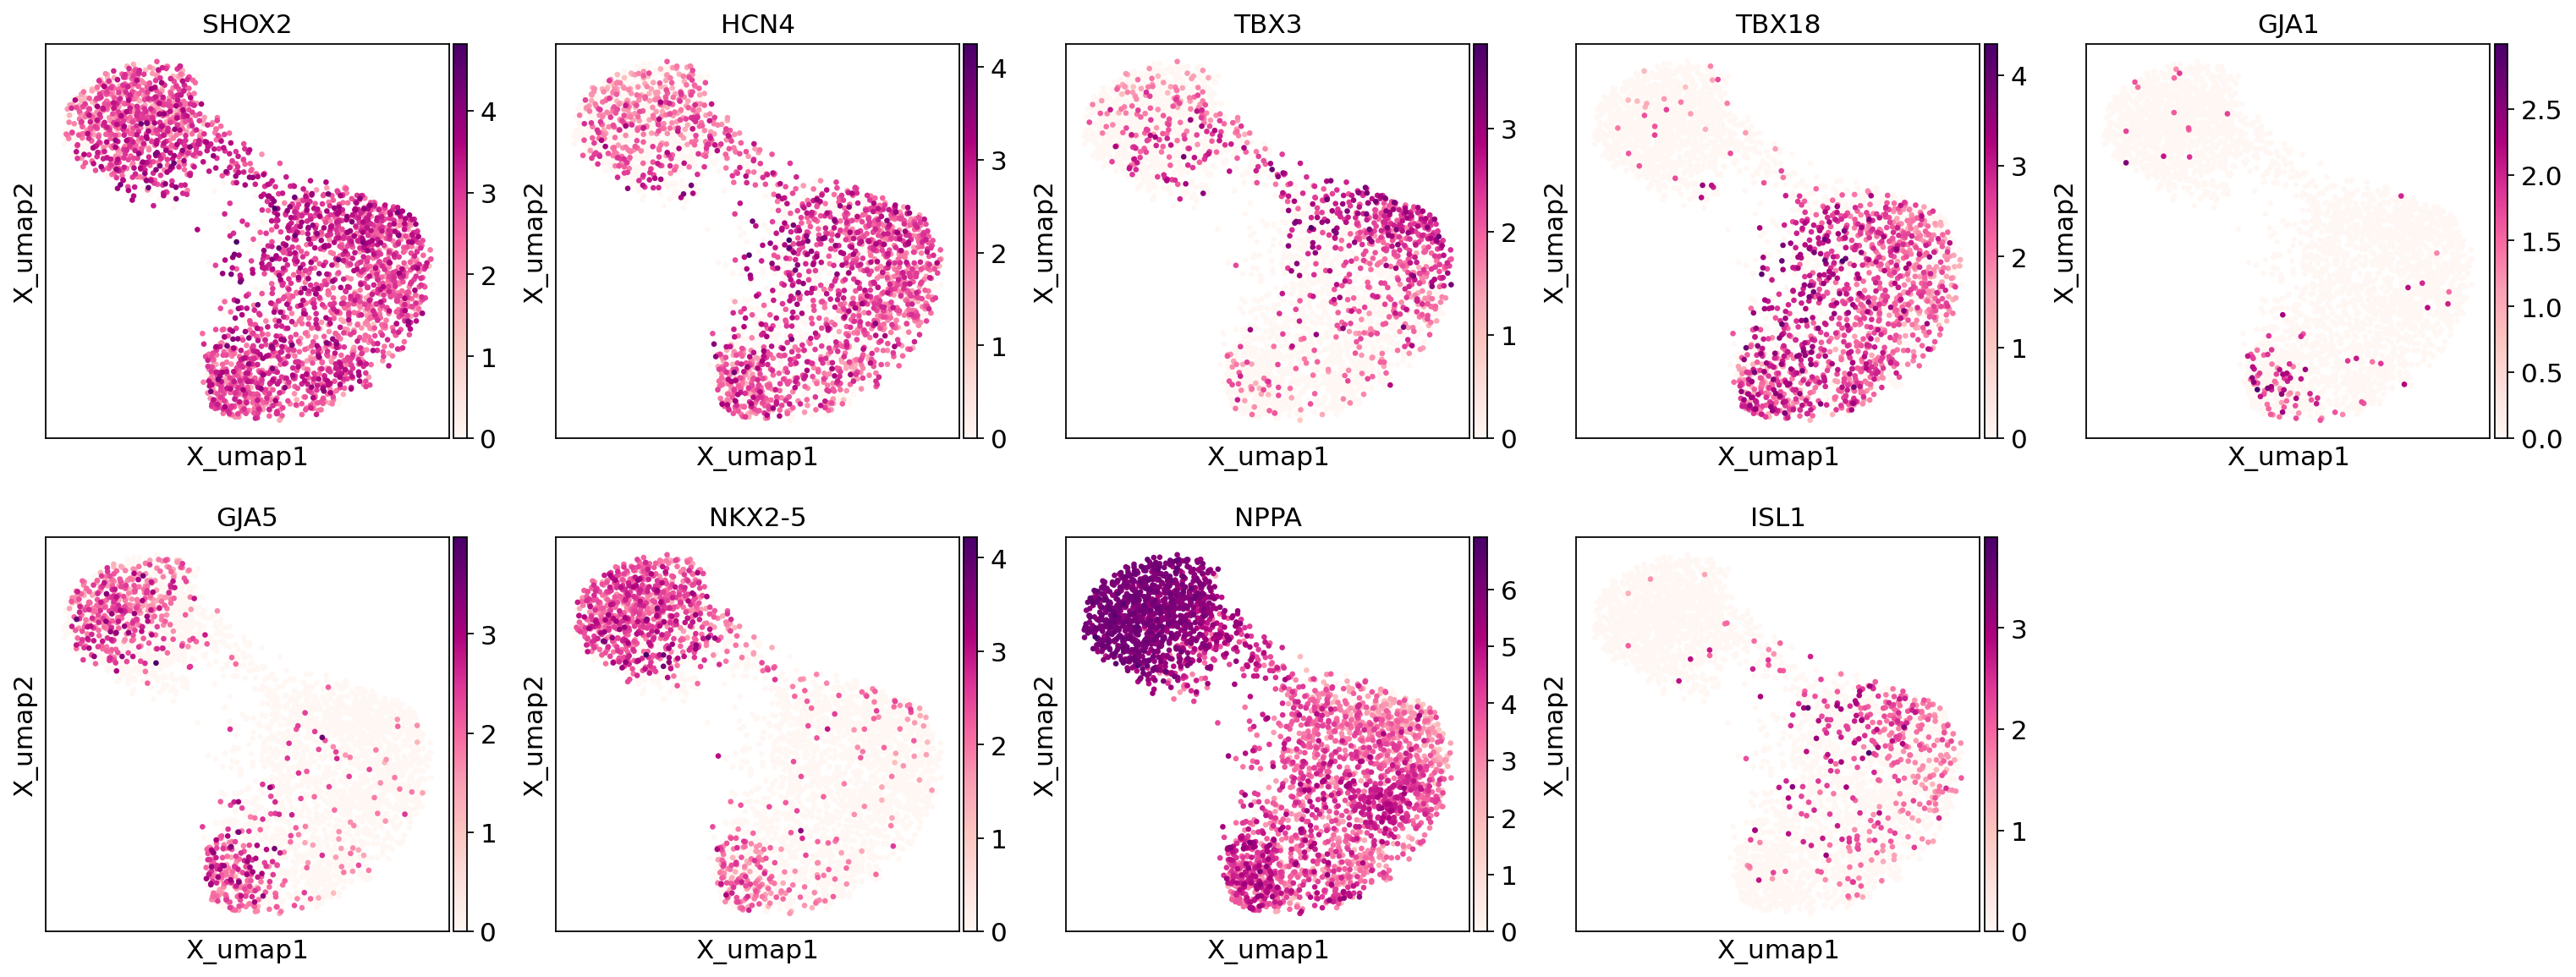

In [14]:
genes = ['SHOX2','HCN4','TBX3','TBX18',
         'GJA1', # CX43
         'GJA5', # CX40
         'NKX2-5',
         'NPPA','ISL1'
        ]
genes = [x for x in genes if x in adata_sub.var_names]
sc.pl.embedding(adata_sub,basis='X_umap',
                color=genes,
               ncols=5, wspace=0.15,cmap='RdPu',vmax='p100')

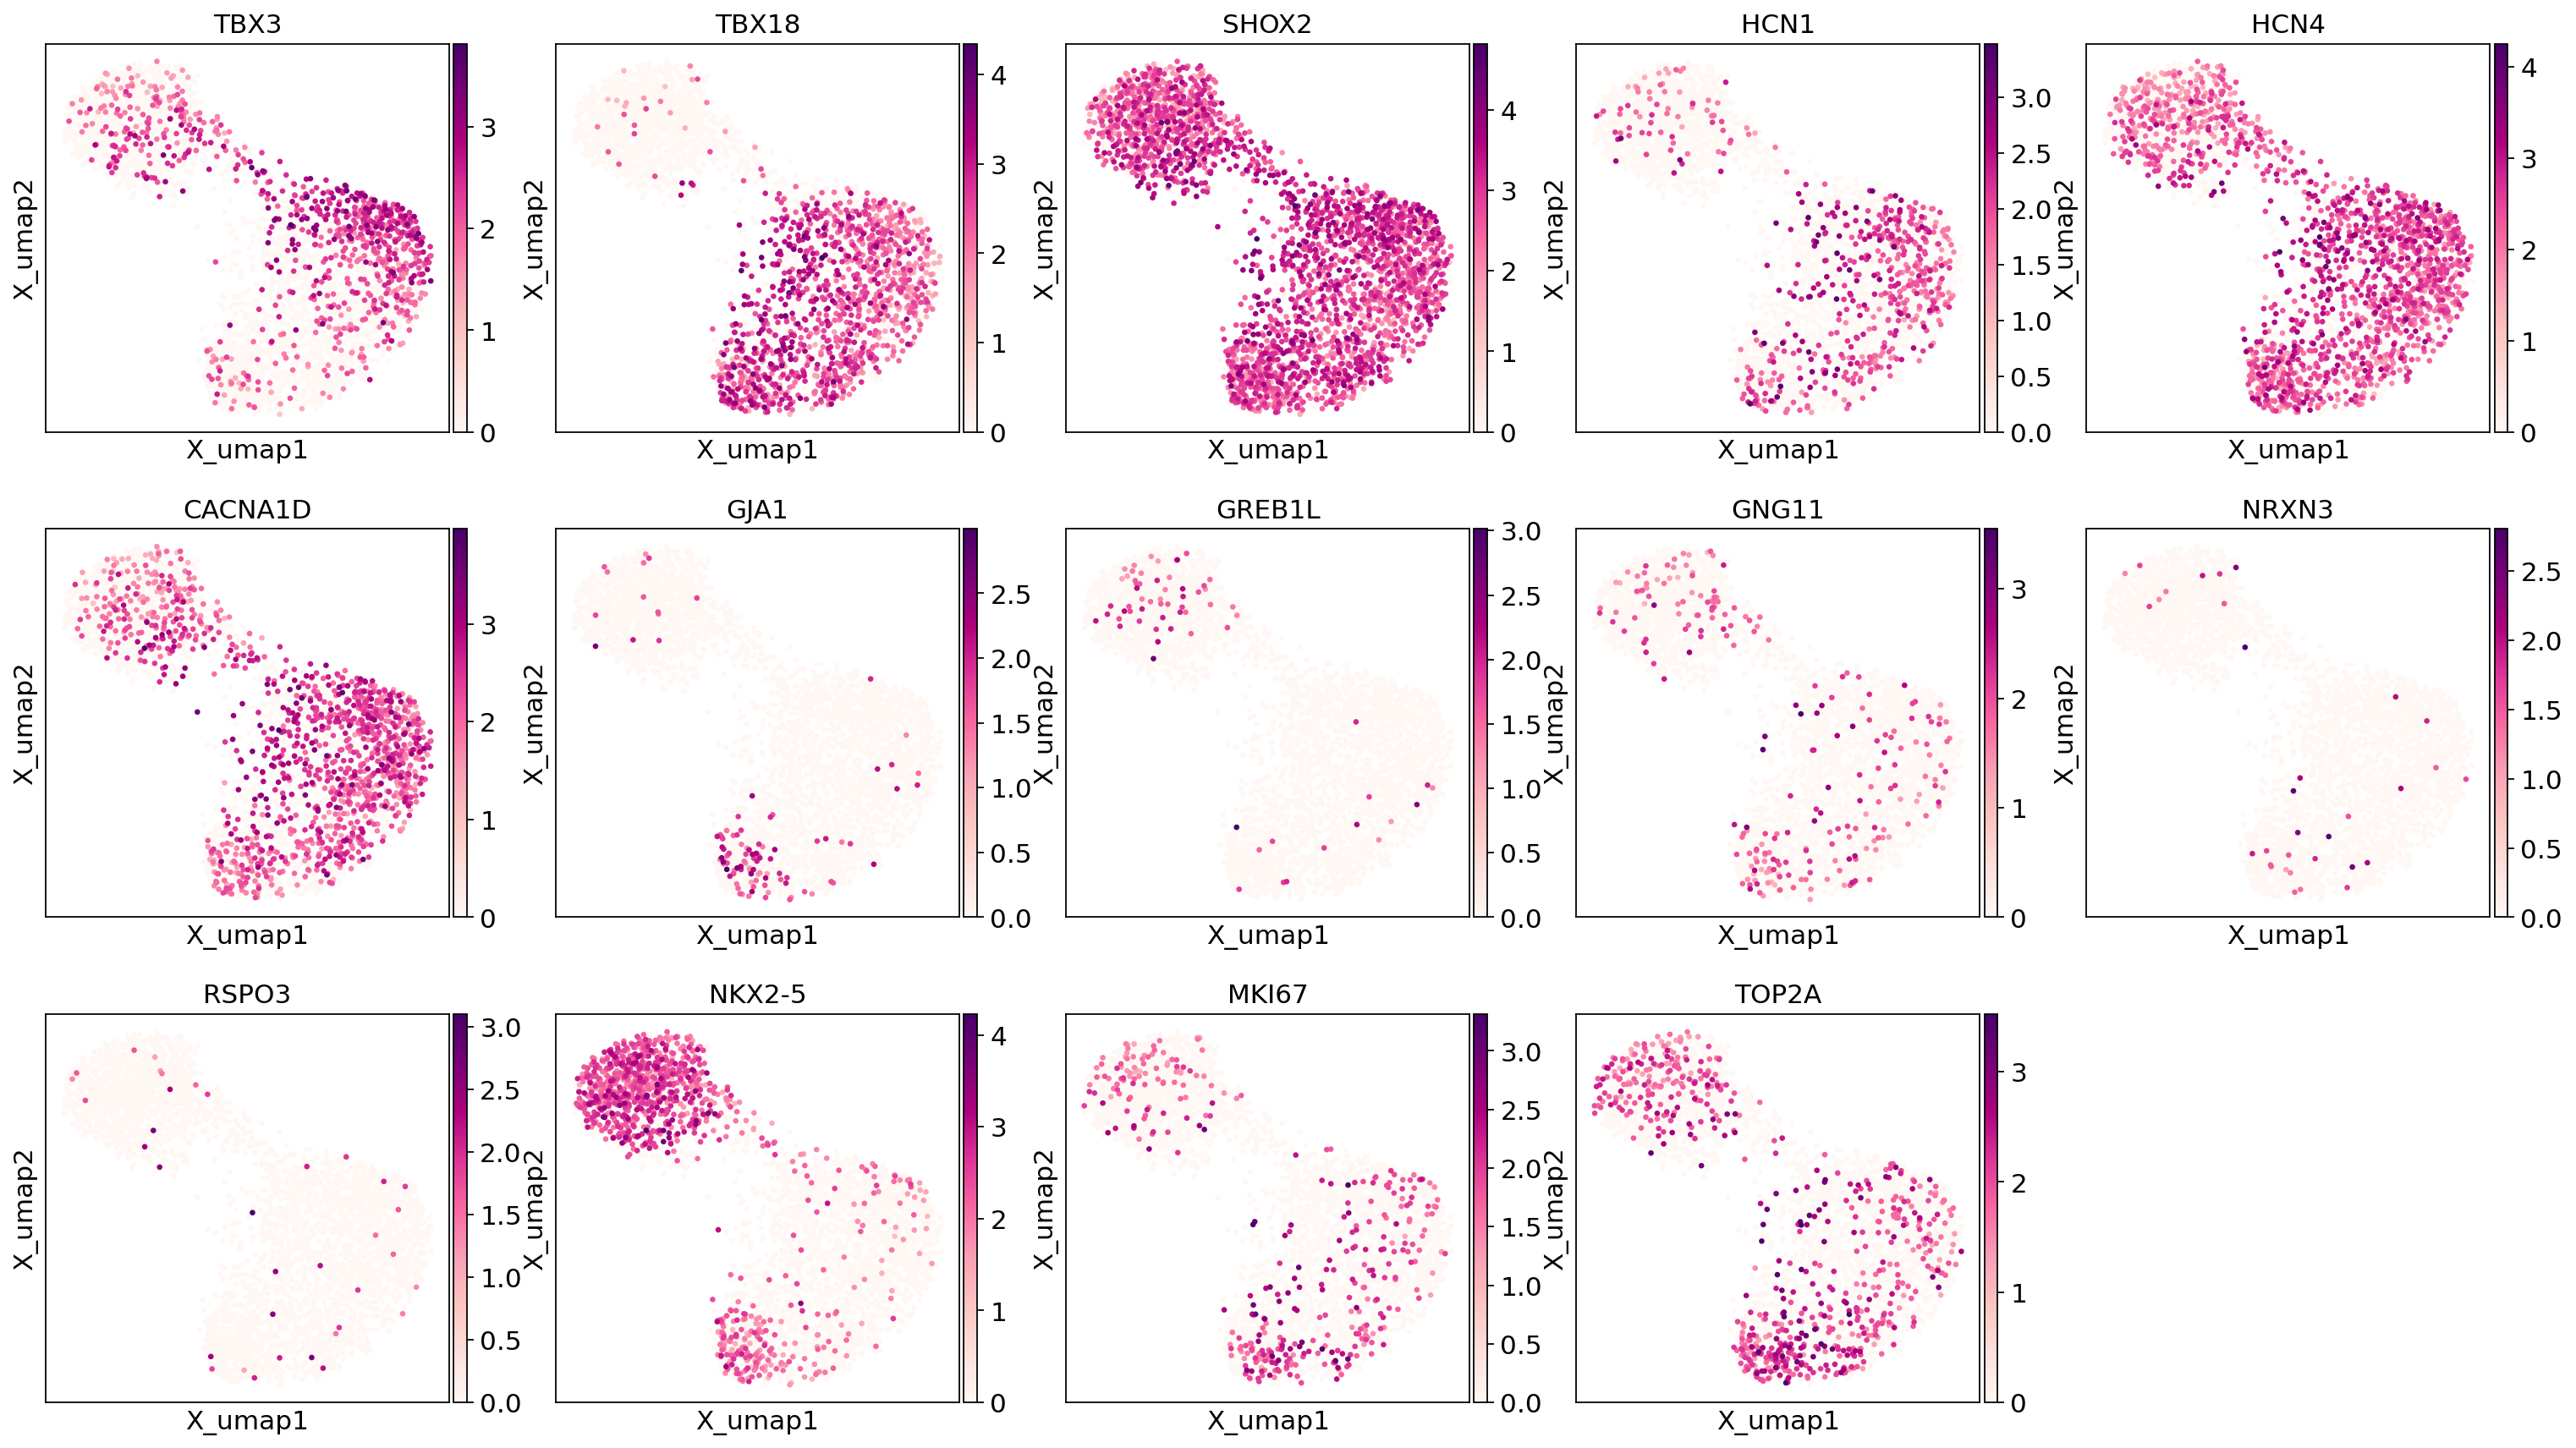

In [15]:
genes = ['TBX3','TBX18','SHOX2','HCN1','HCN4','CACNA1D', 'GJA1',# SANPC
         'GREB1L','GNG11','NRXN3','RSPO3', # AVNPC
         'NKX2-5','MKI67','TOP2A'
        ]
genes = [x for x in genes if x in adata_sub.var_names]
sc.pl.embedding(adata_sub,basis='X_umap',
                color=genes,
               ncols=5, wspace=0.15,cmap='RdPu',vmax='p100')

# Save

In [16]:
adata_sub.write(f'{data_object_dir}/b2c_cells_SinoatrialNodePacemakerCells_lognorm.h5ad')
f'{data_object_dir}/b2c_cells_SinoatrialNodePacemakerCells_lognorm.h5ad'

'/rfs/project/rfs-iCNyzSAaucw/kk837/data_objects/Foetal/VisiumHD/Revision_Oct2025/TACCO/coarse_grain_subsets/b2c_cells_SinoatrialNodePacemakerCells_lognorm.h5ad'

# Plot on sections

In [7]:
adata_sub = sc.read_h5ad(f'{data_object_dir}/b2c_cells_SinoatrialNodePacemakerCells_lognorm.h5ad')

In [8]:
# read in original adata
bdata = sc.read_h5ad(f'/rfs/project/rfs-iCNyzSAaucw/kk837/data_objects/Foetal/VisiumHD/Revision_Oct2025/all_b2c_cells_filtered_raw.h5ad')

bdata.obs['fine_grain'] = 'nan'
bdata.obs.loc[adata_sub.obs_names,'fine_grain'] = adata_sub.obs[celltype_key].copy()

/tmp/ipykernel_341732/3524071468.py:14: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  slide.uns['spatial'] = {s_spatial: slide.uns['spatial'][s_spatial]}
/tmp/ipykernel_341732/804220981.py:9: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(slide, color=['fine_grain'],


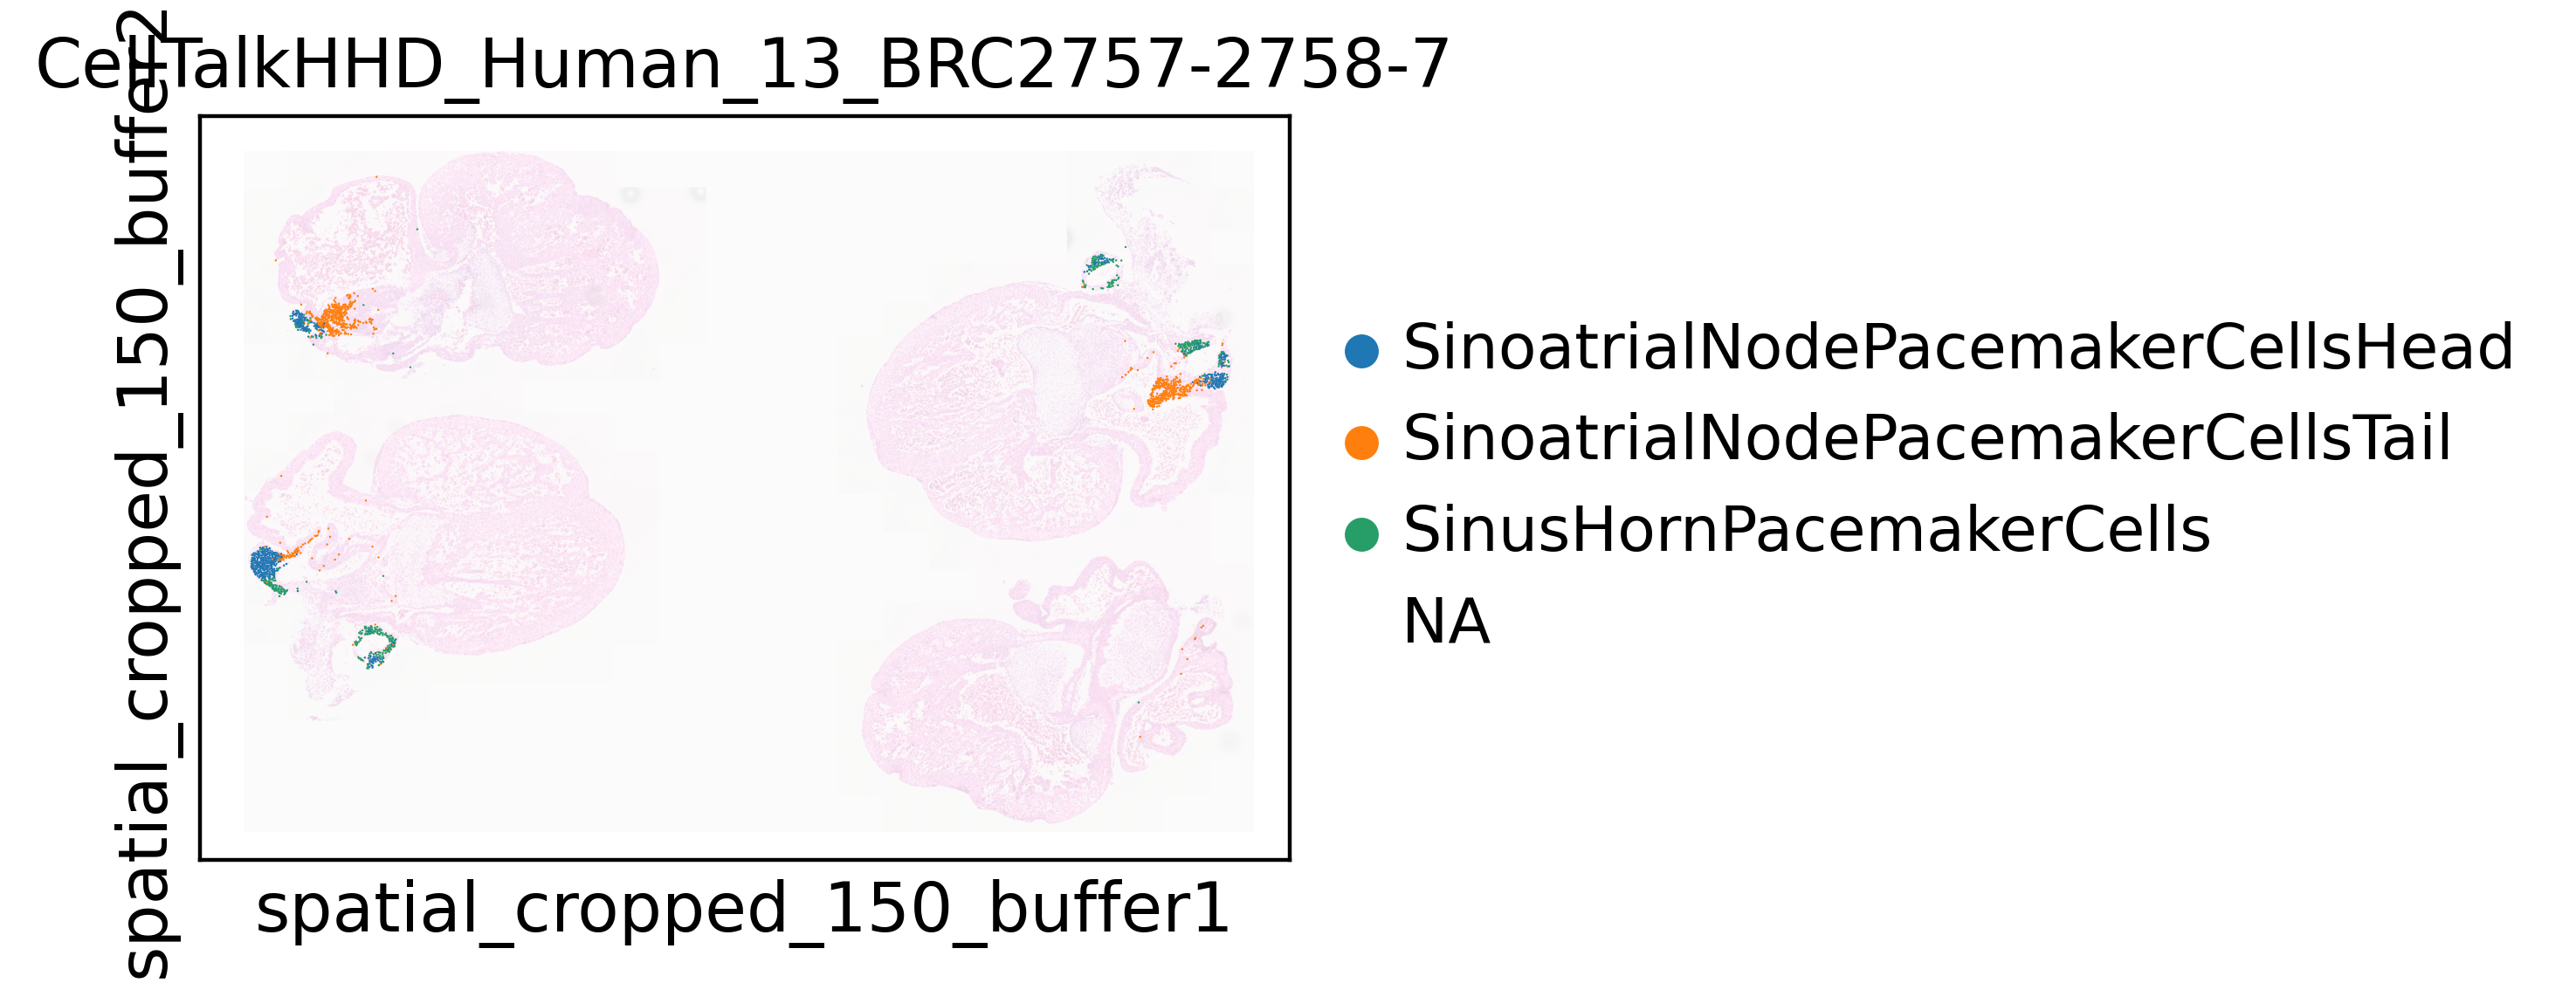

/tmp/ipykernel_341732/3524071468.py:14: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  slide.uns['spatial'] = {s_spatial: slide.uns['spatial'][s_spatial]}
/tmp/ipykernel_341732/804220981.py:9: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(slide, color=['fine_grain'],


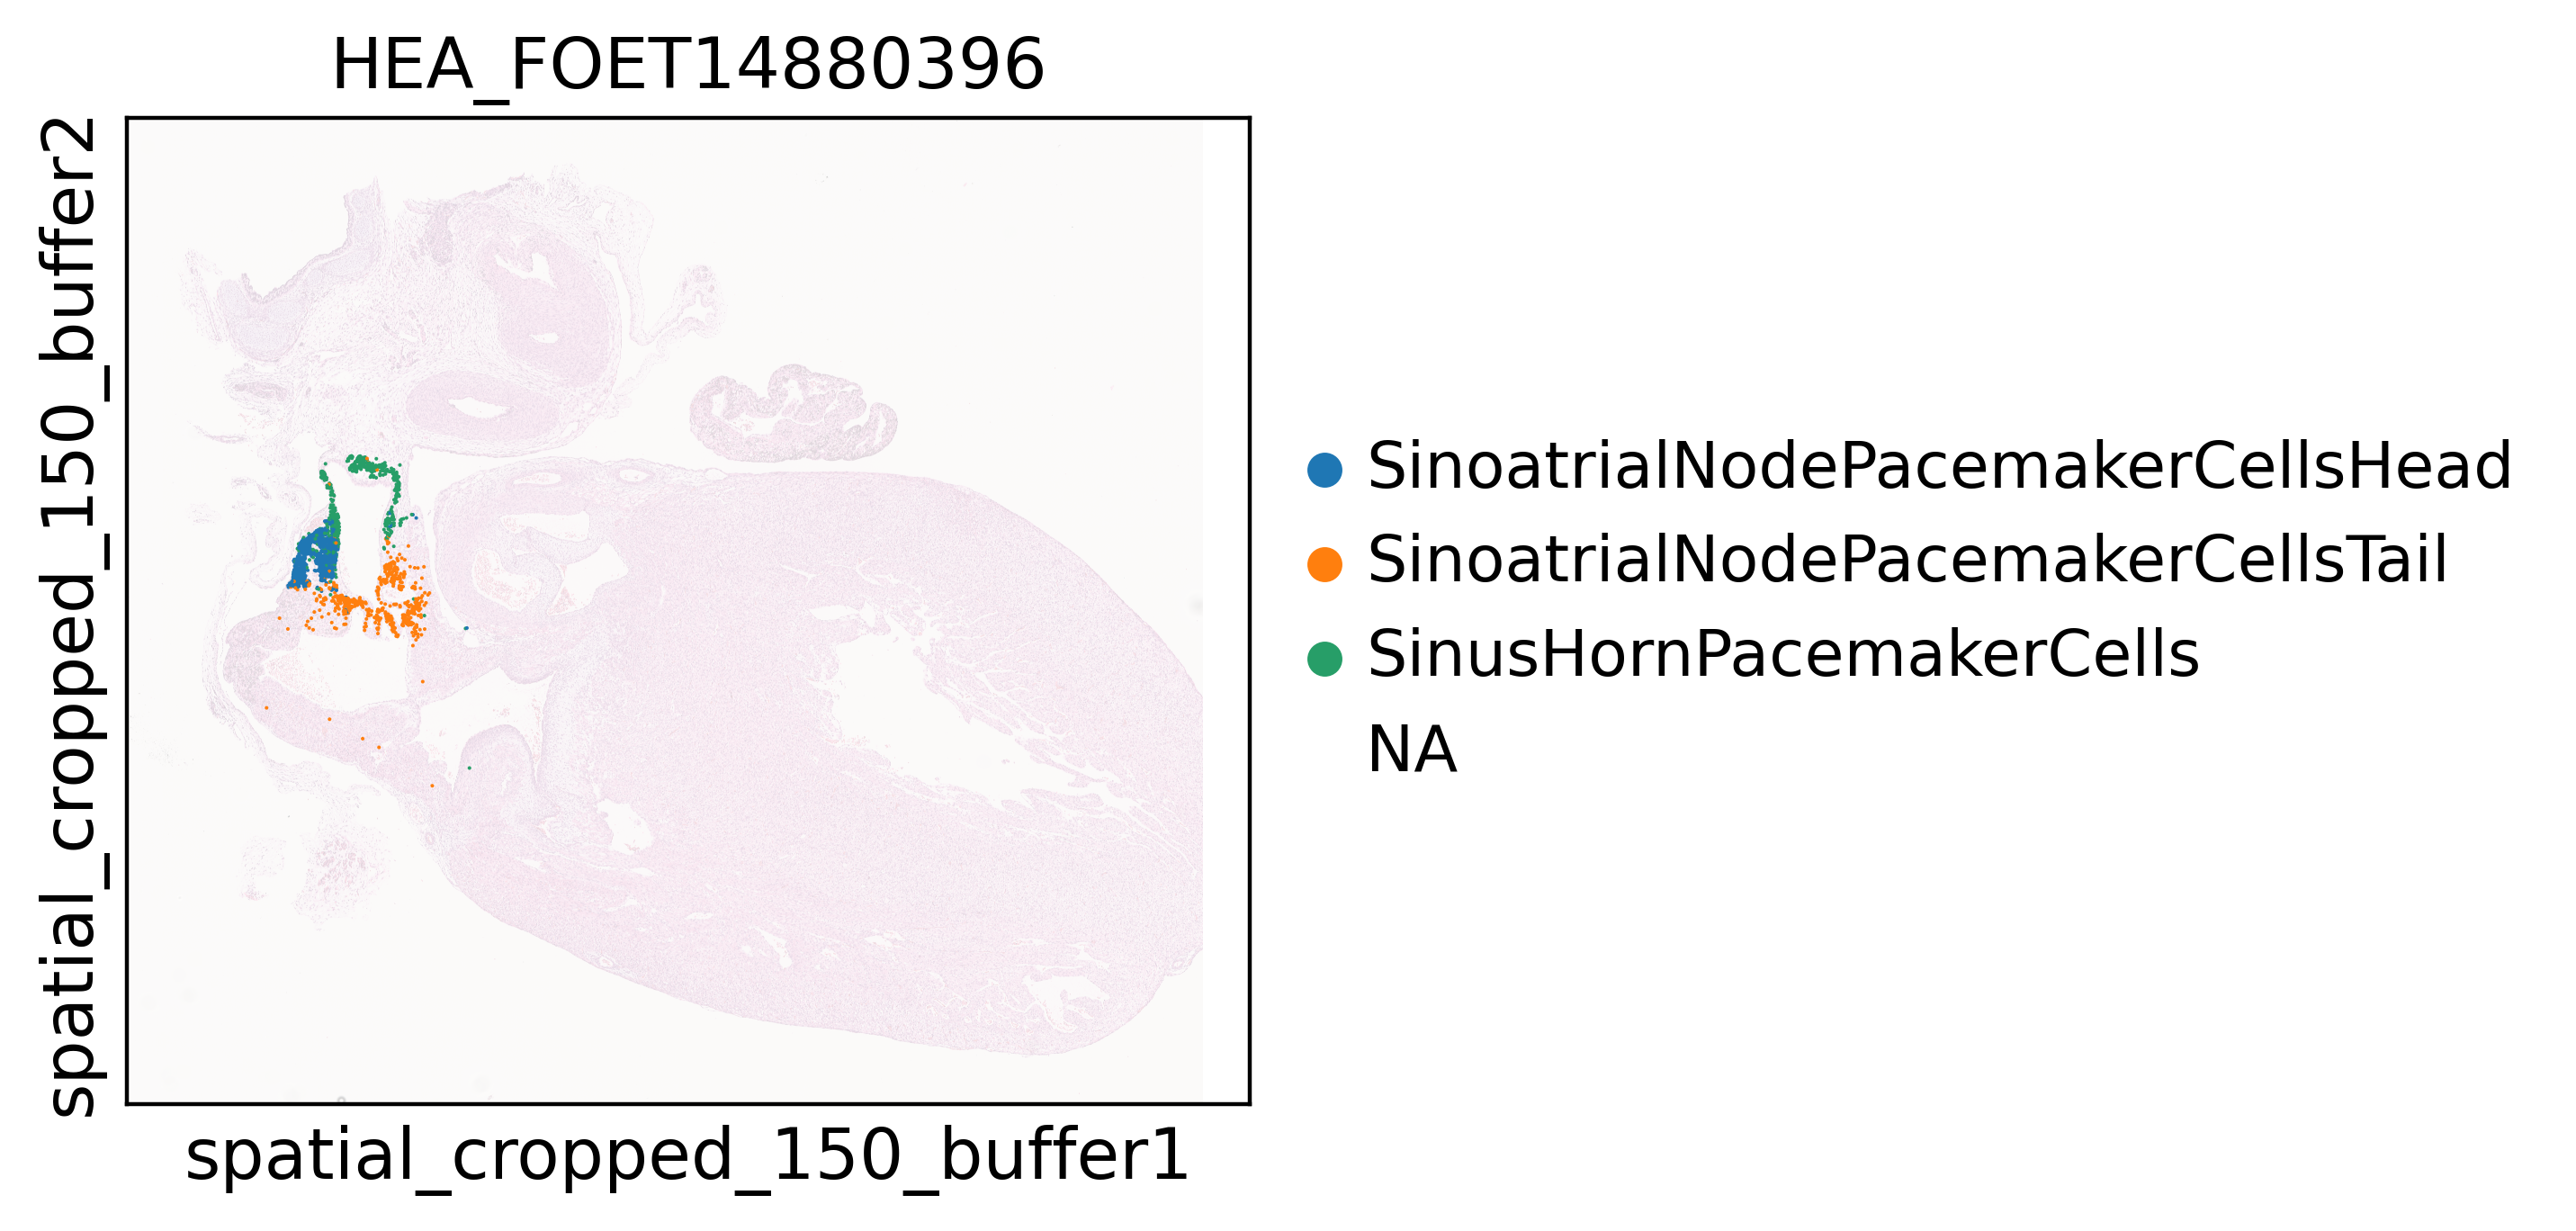

In [10]:
sc.settings.set_figure_params(dpi=200)
# plotting for inspection
sample_list = list(set(bdata.obs['library']))
sample_list.sort()

for sample_id in sample_list:
    # subsetting
    slide = select_slide(bdata, sample_id, s_col='library')
    sc.pl.spatial(slide, color=['fine_grain'], 
                  groups = ['SinusHornPacemakerCells',
                            'SinoatrialNodePacemakerCellsHead',
                            'SinoatrialNodePacemakerCellsTail',
                            
                            ],
                  img_key="0.3_mpp_150_buffer", basis="spatial_cropped_150_buffer",
                  alpha_img=0.2,
                  title=sample_id,spot_size=100)
sc.settings.set_figure_params(dpi=80)